In [68]:
## toxic comments
import pandas as pd
import matplotlib.pyplot as plt
import re



In [69]:
## load the dataset
df = pd.read_csv('toxic-comments.csv')
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [70]:
df.shape

(159571, 8)

In [71]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='str')

In [72]:
#define target variable
toxicities =  ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

In [73]:
comments = df.sum(numeric_only=True)
comments


toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

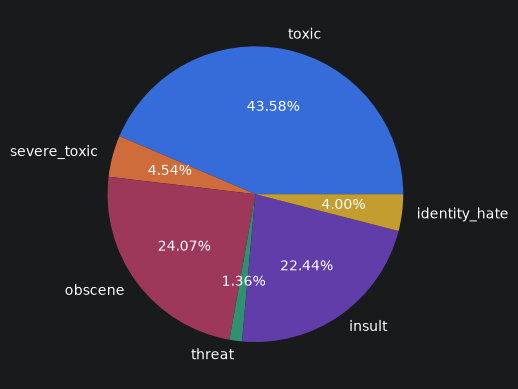

In [74]:
plt.pie(comments.values,labels=comments.index,autopct='%2.2f%%')

In [75]:
total = df.sum(axis=1,numeric_only=True)

In [76]:
new_df = pd.DataFrame({
    'neutral': [sum(total==0)],
    'toxic': [sum(total!=0)],
})
new_df

,neutral,toxic
0,143346,16225


In [77]:
newsr = new_df.iloc[0]
newsr

neutral    143346
toxic       16225
Name: 0, dtype: int64

<BarContainer object of 2 artists>

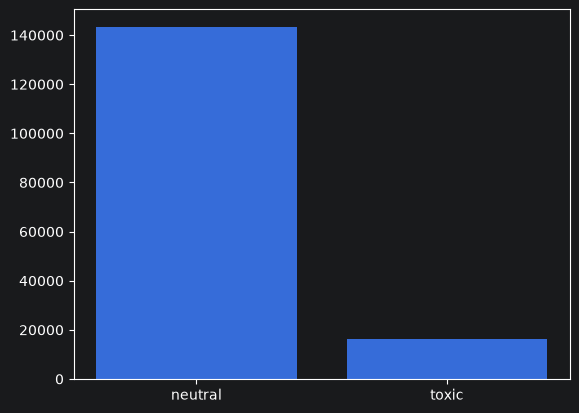

In [78]:
import seaborn as sns
plt.bar(newsr.index, newsr.values)
#sns.countplot([neutral,toxic])

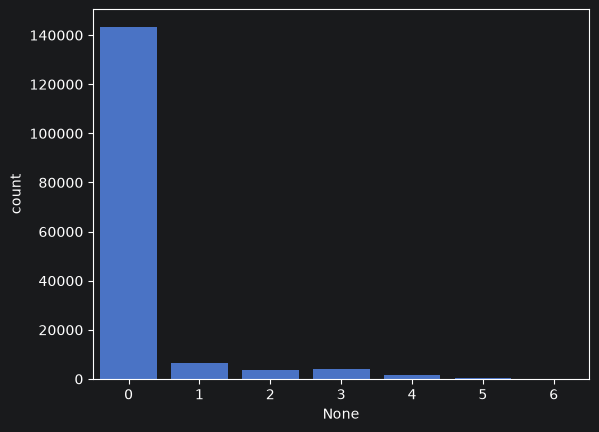

In [79]:
sns.countplot(x =total);


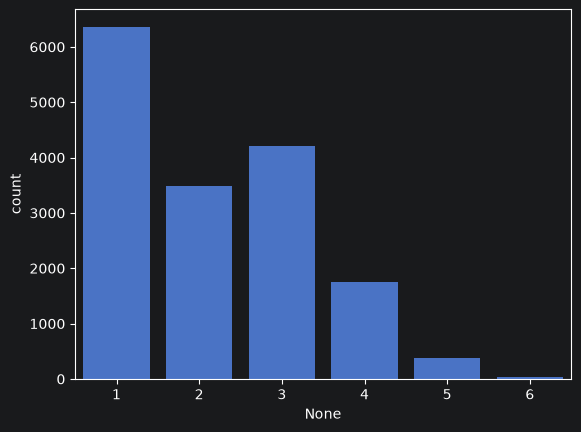

In [80]:
only_toxic = total [total != 0]
sns.countplot (x = only_toxic);

In [81]:
# new_df = pd.DataFrame({
#     'neutral' : [sum(total ==0)],
#     'one_category' : [sum(total==1)],
#     'two_category' : [sum(total==2)],
#     'three_category' : [sum(total==3)],
#     'four_category' : [sum(total==4)],
#     'five_category' : [sum(total==5)],
#     'six_category' : [sum(total==6)]
# })
# new_df

In [82]:
pd.Series(only_toxic).value_counts()

1    6360
3    4209
2    3480
4    1760
5     385
6      31
Name: count, dtype: int64

## Data Cleaning

In [83]:
def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-z0-9]', ' ', text)
    return text

In [84]:
text = ' Hello! How are you?'
clean_text (text)

' hello  how are you '

#input data

In [86]:
comment_text = df['comment_text'].apply(clean_text)
comment_text

0         explanation why the edits made under my userna...
1         d aww  he matches this background colour i m s...
2         hey man  i m really not trying to edit war  it...
3           more i can t make any real suggestions on im...
4         you  sir  are my hero  any chance you remember...
                                ...                        
159566          and for the second time of asking  when ...
159567    you should be ashamed of yourself   that is a ...
159568    spitzer   umm  theres no actual article for pr...
159569    and it looks like it was actually you who put ...
159570      and     i really don t think you understand ...
Name: comment_text, Length: 159571, dtype: str

In [87]:
labels = df[toxicities].values
labels

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]], shape=(159571, 6))

## Prepar input data

In [88]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras. models import Sequential
from keras. layers import Embedding,LSTM, Dense, GRU
from sklearn.model_selection import train_test_split



In [89]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(comment_text)
sequences = tokenizer.texts_to_sequences(comment_text)
padded = pad_sequences(sequences, maxlen=200)
padded.shape


(159571, 200)

In [90]:
padded[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

## Cross Validation

In [91]:
x_train,x_test, y_train,y_test = train_test_split (
    padded, labels, test_size = 0.2)

x_train.shape, y_train.shape

((127656, 200), (127656, 6))

In [92]:
x_test.shape,y_test.shape

((31915, 200), (31915, 6))

## Build the Model

In [98]:
model = Sequential()
model.add(Embedding(5000,100,input_length=200))
model.add(GRU(64))
model.add(Dense(6,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [99]:
model.fit(x_train,y_train,epochs=10, validation_data=(x_test,y_test))


Epoch 1/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 144s 36ms/step - accuracy: 0.9919 - loss: 0.0633 - val_accuracy: 0.9941 - val_loss: 0.0511
Epoch 2/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 146s 36ms/step - accuracy: 0.9904 - loss: 0.0467 - val_accuracy: 0.9891 - val_loss: 0.0479
Epoch 3/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 146s 37ms/step - accuracy: 0.9683 - loss: 0.0414 - val_accuracy: 0.9831 - val_loss: 0.0487
Epoch 4/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 144s 36ms/step - accuracy: 0.9264 - loss: 0.0372 - val_accuracy: 0.8984 - val_loss: 0.0503
Epoch 5/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 146s 37ms/step - accuracy: 0.8559 - loss: 0.0330 - val_accuracy: 0.8580 - val_loss: 0.0549
Epoch 6/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 144s 36ms/step - accuracy: 0.7849 - loss: 0.0292 - val_accuracy: 0.8167 - val_loss: 0.0585
Epoch 7/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 152s 38ms/step - accuracy: 0.7266 - loss: 0.0252 - val_accuracy: 0.7629 - val_loss: 0.0646
Epoch 8/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 145s 36ms/step - accuracy: 

In [106]:
sample_text = 'You are stupid. No one cares about your opinion. Just shut up.'
sample_text1 = 'You are waste of time. World is better without you.'
sample_text2 = 'Your life will be so beautiful with her.'

In [115]:
def predict(new_comment):
  clean_smple_text = clean_text(new_comment)
  clean_smple_text=tokenizer.texts_to_sequences([clean_smple_text])
  clean_smple_text=pad_sequences(clean_smple_text,maxlen=200)

  prediction = model.predict(clean_smple_text, verbose= False)
  for i in range(len(prediction[0])):
    if prediction[0][i] > 0.5:
      print(toxicities[i])

  return prediction

In [136]:
def predict(new_comment):
    clean_smple_text = clean_text(new_comment)
    clean_smple_text = tokenizer.texts_to_sequences([clean_smple_text])
    clean_smple_text = pad_sequences(clean_smple_text, maxlen=200)

    prediction = model.predict(clean_smple_text, verbose=False)

    toxic = False

    for i in range(len(prediction[0])):
        if prediction[0][i] > 0.5:
            print(toxicities[i])
            toxic = True

    if not toxic:
        print("Not toxic")

    return prediction

In [137]:
predict(sample_text)

toxic
insult


array([[9.9876773e-01, 7.2833076e-02, 1.7036152e-01, 1.0906552e-05,
        8.1611919e-01, 8.3537707e-03]], dtype=float32)

In [138]:
predict(sample_text1)

Not toxic


array([[3.01376045e-01, 1.38500036e-04, 1.53280515e-02, 5.55773158e-06,
        3.13929841e-02, 1.54173340e-05]], dtype=float32)

In [139]:
predict(sample_text2)

Not toxic


array([[6.0227998e-02, 4.2179505e-05, 1.5692210e-03, 3.2281579e-05,
        6.9843984e-05, 1.9058194e-05]], dtype=float32)